In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from model import MazeTransformer
import torch
import yaml

MODEL_NAME = "example_untrained"
STATE_DICT_PATH = f'./models/{MODEL_NAME}/model'
with open(f"./models/{MODEL_NAME}/config.yaml", "r") as f:
    config = yaml.safe_load(f)

model = MazeTransformer(config["model"])
model.load_state_dict(torch.load(STATE_DICT_PATH, weights_only=True))
model.eval()

MazeTransformer(
  (embedding_layer): Embedding(10, 256)
  (pos_embedding_layer): Embedding(512, 256)
  (transformer_blocks): ModuleList(
    (0-9): 10 x TransformerBlock(
      (attn): MultiHeadAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1024, out_features=256, bias=True)
        (3): Dropout(p=0, inplace=False)
      )
    )
  )
  (ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=5, bias=True)
)

In [10]:
from supervised import MazeDataset, create_causal_mask
from generate_dataset import generate_dataset
import os

config["dataset"]["output_dir"] = "inference_data"
generate_dataset(config["dataset"])
train_dataset = MazeDataset(os.path.join("./inference_data", "train"))

Generating data for sixteen


100%|██████████| 512/512 [00:00<00:00, 635.09it/s]


In [11]:
sequences, targets, sizes, _ = train_dataset[100]

sequences = sequences.unsqueeze(0)
targets = targets.unsqueeze(0)
sizes = sizes.unsqueeze(0)

seq_len = sequences.shape[1]
masks = create_causal_mask(sizes, seq_len)

sequences = sequences.to(config["model"]["device"])
masks = masks.to(config["model"]["device"])

model_out = model.forward(sequences, masks).squeeze()

sz = sizes.item()
predictions = model_out.squeeze()[sz - 1: sz - 1 + targets[0].shape[0]]

In [12]:
print("Predicted:", torch.argmax(predictions, dim=-1))
print("Target:   ", targets.squeeze())

Predicted: tensor([0, 3, 3, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 3, 3, 3, 0, 0, 3, 0, 3, 3, 0, 3, 0, 0, 0, 0, 3, 3, 0, 3, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 0, 0, 3, 3, 3, 0,
        0, 0, 0, 3, 0, 0, 0, 0, 3, 3, 0, 3, 3, 3, 3, 3, 0, 3, 0, 0, 0, 0, 0, 0,
        0], device='mps:0')
Target:    tensor([3, 3, 3, 3, 0, 3, 3, 1, 3, 3, 3, 0, 0, 3, 3, 0, 0, 0, 2, 0, 2, 0, 2, 0,
        2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 1, 2, 2, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0,
        2, 0, 2, 0, 2, 0, 0, 0, 0, 3, 3, 1, 1, 1, 3, 3, 1, 3, 3, 1, 3, 3, 0, 0,
        0, 0, 3, 3, 0, 3, 3, 1, 1, 2, 1, 1, 1, 3, 3, 0, 3, 3, 0, 0, 2, 0, 0, 3,
        4])


In [14]:
ex_in = sequences[0][:sizes[0]].to('mps')
print(ex_in)
generated_path = model.generate(ex_in, max_tokens=100, method="")
print(generated_path)
print(targets.squeeze())
# print((generated_path == targets[0].to('mps')).all())

tensor([6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 7, 6, 5, 6, 5, 6, 6, 6,
        5, 6, 5, 6, 6, 5, 5, 5, 6, 7, 6, 5, 6, 6, 5, 5, 6, 6, 5, 6, 6, 5, 6, 6,
        6, 6, 7, 6, 5, 5, 6, 6, 6, 5, 6, 6, 6, 5, 5, 6, 5, 5, 5, 7, 6, 6, 5, 6,
        5, 6, 6, 5, 6, 5, 6, 6, 6, 5, 6, 6, 7, 5, 6, 5, 6, 6, 5, 6, 5, 5, 5, 5,
        6, 5, 5, 5, 6, 7, 6, 6, 6, 5, 6, 5, 6, 6, 6, 5, 6, 6, 5, 5, 5, 6, 7, 6,
        5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 6, 7, 6, 5, 5, 6, 6, 6, 5, 6,
        6, 5, 6, 6, 6, 6, 6, 5, 7, 6, 6, 6, 5, 6, 5, 6, 6, 5, 6, 5, 5, 6, 5, 6,
        5, 7, 5, 5, 6, 5, 5, 6, 6, 5, 6, 6, 5, 6, 5, 5, 6, 6, 7, 6, 5, 6, 6, 6,
        6, 5, 6, 6, 5, 6, 6, 6, 6, 5, 6, 7, 6, 5, 5, 5, 5, 5, 6, 6, 5, 6, 6, 5,
        5, 6, 6, 6, 7, 6, 6, 6, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5, 5, 5, 7, 6, 5,
        6, 5, 5, 5, 5, 6, 6, 6, 5, 6, 5, 6, 6, 6, 7, 6, 5, 6, 6, 6, 6, 6, 6, 5,
        6, 6, 6, 6, 6, 5, 6, 7, 8], device='mps:0')
Original softmax prediction: tensor([0.5944, 0.0622, 0.0913, 0.2010,

In [15]:
from torch.utils.data import DataLoader

from train import maze_collate_fn

ex_dataloader = DataLoader(train_dataset, batch_size=config["model"]["batch_size"], collate_fn=maze_collate_fn)
for batch in ex_dataloader:
    ex_batch = batch
    break

In [30]:
sequences, targets, sizes, dataset_names = ex_batch
sequences.shape # (batch_size, padded_seq_len)

torch.Size([128, 384])

In [45]:
s, q, sz, _ = train_dataset[0]
s

tensor([6, 6, 5, 6, 6, 5, 6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 7, 5, 6, 6, 6, 5, 6, 6,
        6, 6, 5, 6, 5, 6, 5, 5, 6, 7, 6, 5, 5, 6, 5, 6, 5, 5, 5, 6, 6, 6, 5, 5,
        5, 6, 7, 6, 5, 6, 6, 5, 6, 6, 6, 5, 6, 5, 6, 6, 5, 6, 6, 7, 6, 6, 5, 6,
        6, 5, 5, 6, 6, 5, 6, 5, 6, 6, 6, 5, 7, 5, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6,
        6, 5, 5, 6, 6, 7, 6, 6, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6, 6, 6, 5, 6, 7, 6,
        5, 6, 6, 5, 6, 6, 5, 6, 6, 6, 5, 6, 5, 6, 6, 7, 6, 6, 6, 5, 5, 5, 6, 6,
        5, 6, 5, 6, 6, 5, 5, 6, 7, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 6,
        6, 7, 6, 5, 5, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 5, 5, 6, 7, 6, 6, 6, 5, 5,
        6, 5, 6, 5, 6, 6, 5, 6, 5, 6, 6, 7, 6, 5, 6, 6, 5, 6, 6, 5, 6, 6, 5, 6,
        6, 5, 6, 5, 7, 6, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6, 6, 5, 6, 6, 6, 7, 6, 6,
        5, 6, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 7, 5, 6, 5, 6, 6, 6, 6, 6, 6,
        6, 5, 6, 6, 6, 6, 6, 7, 8, 0, 3, 0, 0, 3, 3, 3, 3, 1, 1, 3, 1, 3, 3, 0,
        0, 3, 0, 3, 0, 0, 3, 3, 0, 3, 3,

In [6]:
import torch

a = torch.randint(0, 5, (3, 3))
b = torch.tensor([0, 2, 1])

a

tensor([[2, 2, 2],
        [1, 2, 4],
        [4, 4, 1]])

In [9]:
a[torch.arange(3), b]

tensor([2, 4, 4])

### Generating a big maze

In [10]:
from maze import generate_maze, solve_maze, convert_to_directions
from tokenizer import tokenize

MAZE_SIZE = 16
maze = generate_maze(MAZE_SIZE)
path = convert_to_directions(solve_maze(maze))

tokenized, maze_size = tokenize(maze, path)
maze_tokens = torch.tensor(tokenized[:maze_size]).to("cuda")

print(maze_tokens)

tensor([6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 5, 5, 6, 5, 6, 6, 7, 6, 6, 6, 5, 5, 6, 5,
        6, 5, 6, 6, 6, 6, 6, 6, 5, 7, 5, 5, 5, 6, 5, 6, 6, 5, 6, 5, 6, 5, 5, 5,
        6, 6, 7, 6, 6, 5, 6, 5, 5, 6, 6, 6, 6, 6, 5, 6, 5, 6, 5, 7, 5, 6, 6, 6,
        6, 6, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 7, 6, 6, 5, 6, 5, 6, 5, 6, 6, 6, 5,
        6, 6, 5, 5, 6, 7, 6, 5, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 7, 6,
        5, 6, 6, 5, 5, 6, 5, 6, 5, 6, 5, 6, 6, 5, 6, 7, 6, 6, 5, 6, 6, 6, 5, 6,
        6, 5, 6, 6, 6, 5, 6, 5, 7, 5, 6, 6, 5, 6, 5, 6, 6, 5, 6, 6, 5, 5, 6, 6,
        6, 7, 6, 5, 6, 5, 6, 6, 6, 5, 6, 5, 6, 5, 6, 5, 5, 6, 7, 6, 6, 6, 5, 5,
        6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 6, 7, 6, 5, 5, 6, 6, 6, 5, 6, 5, 6, 6, 6,
        5, 5, 5, 6, 7, 6, 6, 5, 6, 5, 6, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 6,
        5, 6, 6, 5, 6, 6, 5, 5, 6, 5, 6, 5, 5, 5, 7, 6, 6, 6, 6, 5, 5, 5, 6, 6,
        6, 6, 5, 6, 6, 6, 6, 7, 8], device='cuda:0')


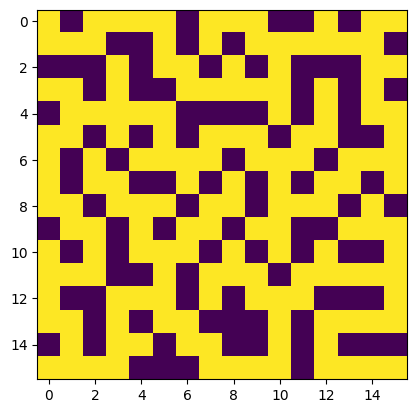

In [11]:
import matplotlib.pyplot as plt

maze_arr = maze_tokens.cpu().numpy()[:-1].reshape((MAZE_SIZE, MAZE_SIZE + 1))[:, :-1]
plt.imshow(maze_arr)

In [9]:
d = {
    0 : "right",
    1 : "left",
    2 : "up",
    3 : "down",
    4 : "eos"
}

model_out = model.generate(maze_tokens).cpu().numpy()
directions = [d[item] for item in model_out]
print(directions)

['right', 'down', 'down', 'down', 'left', 'down', 'down', 'right', 'right', 'down', 'right', 'down', 'right', 'right', 'right', 'right', 'eos']


In [90]:
model.generate(maze_tokens)

tensor([0, 0, 3, 0, 0, 2, 0, 0, 3, 3, 3, 0, 3, 3, 3, 3, 4], device='cuda:0')